In [1]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df_fitur = pd.read_csv("../data/manifest_fitur.csv")
scaler = joblib.load("../models/scaler.joblib")
model = joblib.load("../models/svm_model_v1.joblib")

feature_cols = ["contrast", "correlation", "energy", "homogeneity", "hue", "saturation", "value"]
X = df_fitur[feature_cols].values
y = df_fitur["label"].values
X_scaled = scaler.transform(X)

In [2]:
print("=== RINGKASAN DATASET ===")
print(f"Total crop biji (setelah pembersihan outlier): {len(df_fitur)}")
print(df_fitur['label'].value_counts())
print(f"\nJumlah fitur: {len(feature_cols)} ({', '.join(feature_cols)})")

=== RINGKASAN DATASET ===
Total crop biji (setelah pembersihan outlier): 235
label
sehat             146
terkontaminasi     89
Name: count, dtype: int64

Jumlah fitur: 7 (contrast, correlation, energy, homogeneity, hue, saturation, value)


=== HASIL EVALUASI MODEL FINAL (SVM RBF) ===
                precision    recall  f1-score   support

         sehat       0.96      0.90      0.93        29
terkontaminasi       0.85      0.94      0.89        18

      accuracy                           0.91        47
     macro avg       0.91      0.92      0.91        47
  weighted avg       0.92      0.91      0.92        47



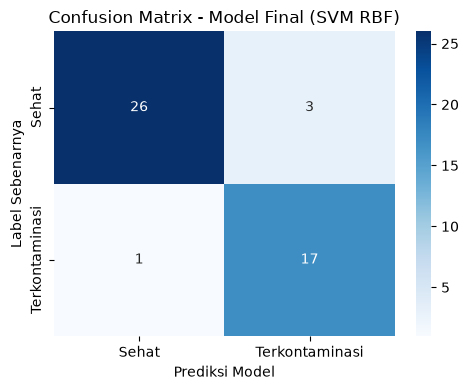

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

y_pred = model.predict(X_test)

print("=== HASIL EVALUASI MODEL FINAL (SVM RBF) ===")
print(classification_report(y_test, y_pred, labels=["sehat", "terkontaminasi"]))

cm = confusion_matrix(y_test, y_pred, labels=["sehat", "terkontaminasi"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Sehat", "Terkontaminasi"],
            yticklabels=["Sehat", "Terkontaminasi"], ax=ax)
ax.set_xlabel("Prediksi Model")
ax.set_ylabel("Label Sebenarnya")
ax.set_title("Confusion Matrix - Model Final (SVM RBF)")
plt.tight_layout()
plt.savefig("../results/confusion_matrix_final.png", dpi=150)
plt.show()

In [4]:
perbandingan = pd.DataFrame({
    "Model": ["Baseline (RBF, default)", "Tuned (Poly, C=1, gamma=1)"],
    "F1-macro (RepeatedStratifiedKFold, 50x)": [0.7817, 0.7844],
    "Std F1-macro": [0.0787, 0.0743],
    "Akurasi Test (1x split)": [0.8095, 0.9524]
})
print("=== PERBANDINGAN BASELINE VS TUNED ===")
print(perbandingan.to_string(index=False))
print("""
Catatan: Selisih F1-macro antara baseline dan tuned (0.0027) jauh lebih kecil
dibanding variasi/std masing-masing (~0.07-0.08), sehingga secara statistik
belum bisa dianggap tuned benar-benar lebih unggul dari baseline pada skala
dataset ini (103 data, 2 kelas). Model final untuk saat ini menggunakan
kernel RBF baseline karena lebih sederhana. Evaluasi ulang akan dilakukan
setelah dataset ditambah.
""")

=== PERBANDINGAN BASELINE VS TUNED ===
                     Model  F1-macro (RepeatedStratifiedKFold, 50x)  Std F1-macro  Akurasi Test (1x split)
   Baseline (RBF, default)                                   0.7817        0.0787                   0.8095
Tuned (Poly, C=1, gamma=1)                                   0.7844        0.0743                   0.9524

Catatan: Selisih F1-macro antara baseline dan tuned (0.0027) jauh lebih kecil
dibanding variasi/std masing-masing (~0.07-0.08), sehingga secara statistik
belum bisa dianggap tuned benar-benar lebih unggul dari baseline pada skala
dataset ini (103 data, 2 kelas). Model final untuk saat ini menggunakan
kernel RBF baseline karena lebih sederhana. Evaluasi ulang akan dilakukan
setelah dataset ditambah.

